In [1]:
%cd /home/govind/gov_semproject/GridCellsCopy

/home/govind/gov_semproject/GridCellsCopy


1.0005072145190424e-06
current density  0.9994930426171028
(108,)


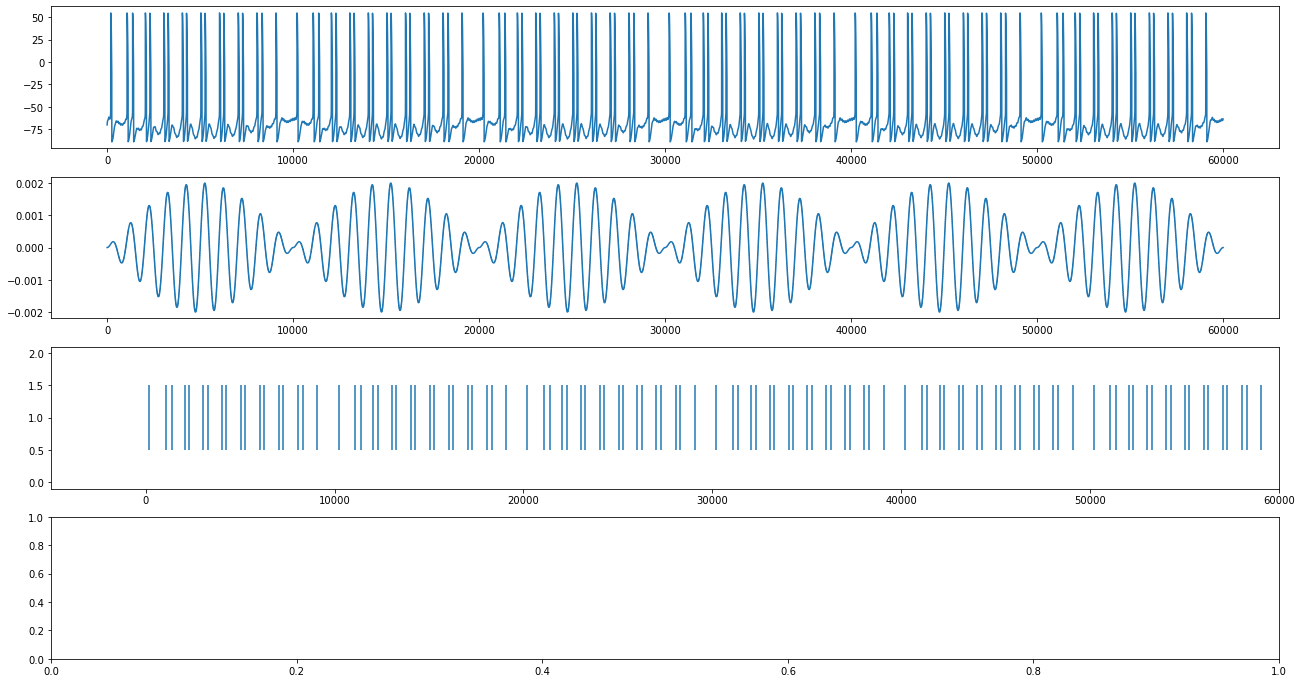

In [2]:
import interneuron
import analysis_utils as a_utils
import numpy as np
import matplotlib.pyplot as plt
from neuron import h
import importlib
importlib.reload(interneuron)

h.load_file("stdrun.hoc")
h.cvode_active(1)

test_interneuron = interneuron.Interneuron(0)
sf_area = h.area(0.5,sec=test_interneuron.soma) * 1e-8
print(sf_area)
ic = h.IClamp(test_interneuron.soma(0.5))
ic.dur = 1e9
T, num_steps = 60,60000
time_arr = np.linspace(0,T,num_steps)

freq = 1
curr_amp = 2e-3
base_amp = 1e-3
print("current density ", base_amp/(1000*sf_area))
baseline_arr = np.full_like(len(time_arr),base_amp)
amp_mod = np.abs(np.sin(2*np.pi*0.05*time_arr))
osc_arr =  (curr_amp * (np.sin(2*np.pi*freq*time_arr))) + baseline_arr

curr_arr = np.zeros(len(time_arr)) 
"""
curr_arr[10001:15000]=1.0e-4
curr_arr[15000:20000]=1.25e-4
curr_arr[20000:25000]=1.3e-4
curr_arr[25000:30000]=1.35e-4
curr_arr[30000:35000]=1.5e-4

curr_arr[30000:35000]=1e-3
curr_arr[35000:40000]=1e-3
curr_arr[40000:45000]=1.5e-3
"""

curr_vec = h.Vector(osc_arr*amp_mod)

curr_vec.play(ic, ic._ref_amp, True)
rec_i = h.Vector().record(ic._ref_amp)
rec_v = h.Vector().record(test_interneuron.soma(0.5)._ref_v)
rec_t = h.Vector().record(h._ref_t)
spike_times = h.Vector()
nc = h.NetCon(test_interneuron.soma(0.5)._ref_v, None, sec=test_interneuron.soma)
nc.threshold=1
nc.record(spike_times)




h.finitialize(-70)
h.continuerun(60000)

np_spike_times=np.array(spike_times.to_python())
print(np.shape(np_spike_times))
fig,ax=plt.subplots(4,1,figsize=(22,12))
ax[0].plot(rec_t, rec_v)
ax[1].plot(rec_t, rec_i)
ax[2].eventplot(spike_times)
ax[2].set_xlim(-5000,60000)
plt.show()


In [20]:
firing_rate = a_utils.instant_rate(spike_train=spike_times,stdev=30,sim_dur=60000)

binned_spks = a_utils.bin_spike_ms([spike_times,spike_times],sim_dur=60000)
print(np.shape(binned_spks))

from scipy.signal import fftconvolve

def gaussian_kernel(sigma_ms,dt=0.001,truncate=5.0):
    sigma_s = sigma_ms/1000.0
    sigma_bins = sigma_s/dt
    n = int(np.ceil(truncate*sigma_bins))
    x=np.arange(-n,n+1)
    g=np.exp(-0.5 * (x/sigma_bins)**2)
    g=g/(g.sum()*dt)
    return g

def firing_rate_from_binary(spikes,sigma_ms,dt=0.001):
    print(len(spikes))
    g = gaussian_kernel(sigma_ms,dt)
    print(len(g))
    rate = fftconvolve(spikes,g,mode='same')
    return rate



(2, 60000)


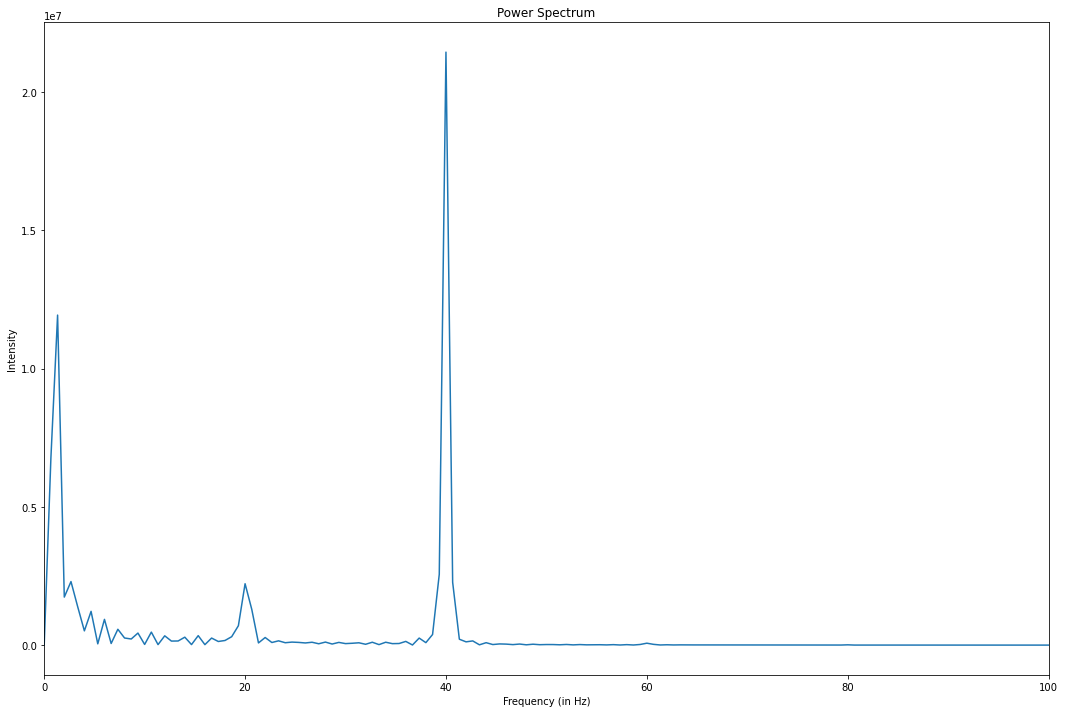

In [178]:
import g_utils
g_utils.plot_power_spectrum(rate,xmax=100)

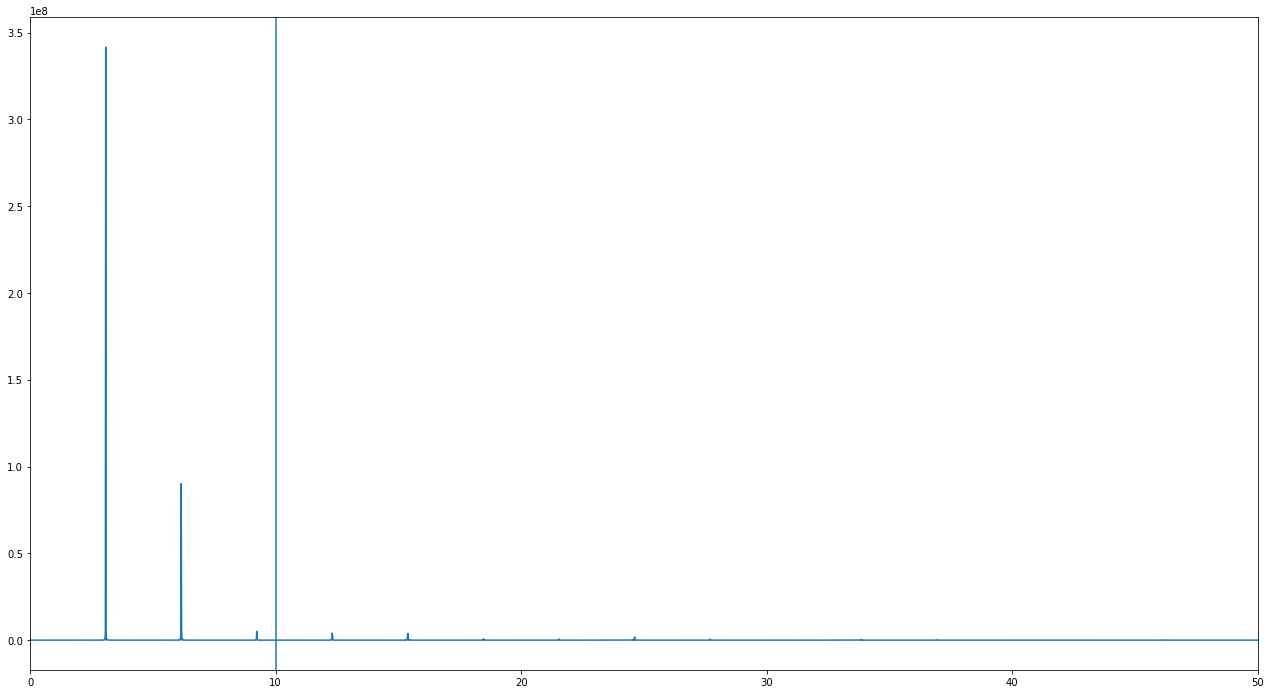

In [161]:
t_s = rec_t/1000
dt = t_s[1]-t_s[0]
fs=1/dt
v_centered = rec_v - np.mean(np.array(rec_v))
n=len(v_centered)
fft_vals = np.fft.rfft(v_centered)
fft_freqs = np.fft.rfftfreq(n,dt)
pow_spec = (np.abs(fft_vals)**2)/n
plt.figure(figsize=(22,12))
plt.plot(fft_freqs,pow_spec)
plt.axvline(x=10)
plt.xlim(0,50)
plt.show()

In [3]:
del rec_v, rec_t,rec_i,spike_times,nc,ic

#### Construct f-I curve for the interneuron


area in cm2 :  1.0005072145190424e-06
current density in ua/cm2 :  9.994930426171028e-06
(20,)
(200000,)


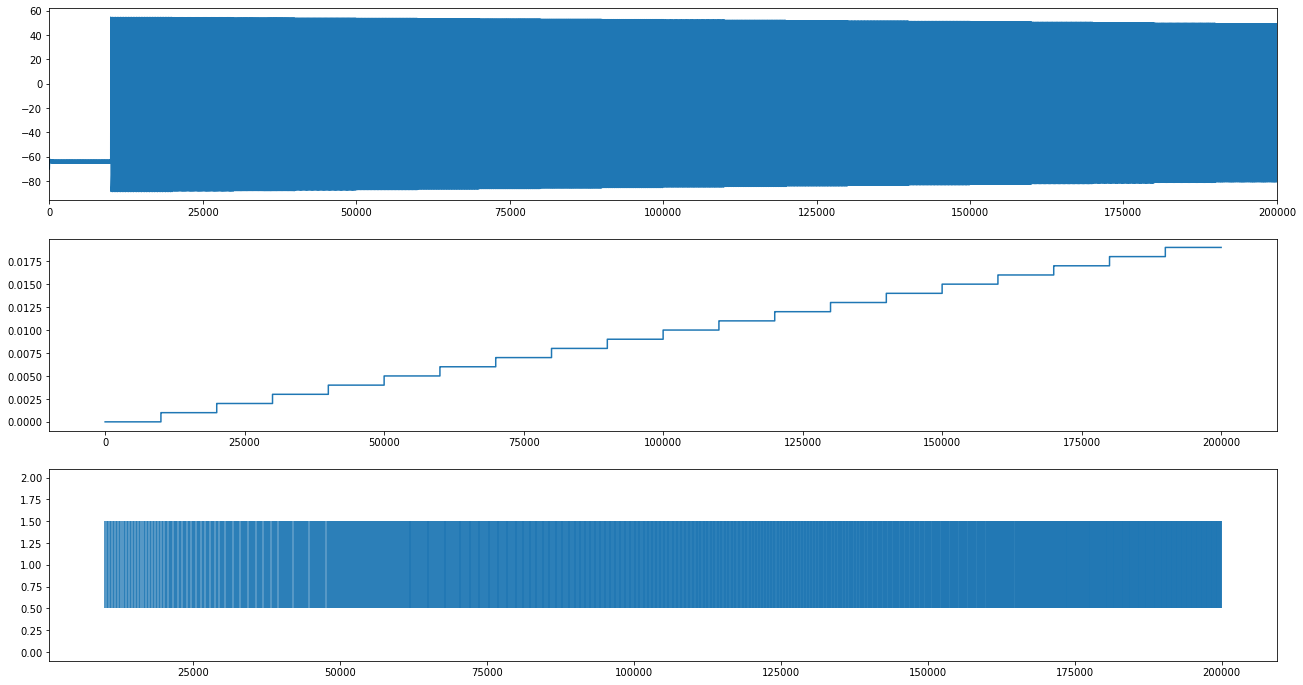

In [68]:
sample_intrnrn = interneuron.Interneuron(2)

sf_area = sample_intrnrn.soma(0.5).area()
print("area in cm2 : ",sf_area*1e-8)
i_na = 1
print("current density in ua/cm2 : ", i_na*1e-3/sf_area)
curr_amp_list = [(i)*1e-3 for i in range(0,20,1)]
print(np.shape(curr_amp_list))
sigma_ms = 1000
T, num_steps = 200,200000
time_arr = np.linspace(0,T,num_steps)


ic = h.IClamp(sample_intrnrn.soma(0.5))
ic.dur = 1e9
curr_amp = np.zeros(len(time_arr))
print(np.shape(curr_amp))
for i in range(0,20,1):
    curr_amp[i*10000:(i*10000)+10000] = curr_amp_list[i]
    
curr_vec = h.Vector(curr_amp)

curr_vec.play(ic, ic._ref_amp, True)
rec_i = h.Vector().record(ic._ref_amp)
rec_v = h.Vector().record(sample_intrnrn.soma(0.5)._ref_v)
rec_t = h.Vector().record(h._ref_t)
spike_times = h.Vector()
nc = h.NetCon(sample_intrnrn.soma(0.5)._ref_v, None, sec=sample_intrnrn.soma)
nc.threshold=0
nc.record(spike_times)
h.finitialize(-70)
h.continuerun(200000)

fig,ax=plt.subplots(3,1,figsize=(22,12))
ax[0].plot(rec_t, rec_v)
ax[1].plot(rec_t, rec_i)
ax[2].eventplot(spike_times)
ax[0].set_xlim(0,200000)
plt.show()



    

    

    
    


200000
5001
shape  (200000,)


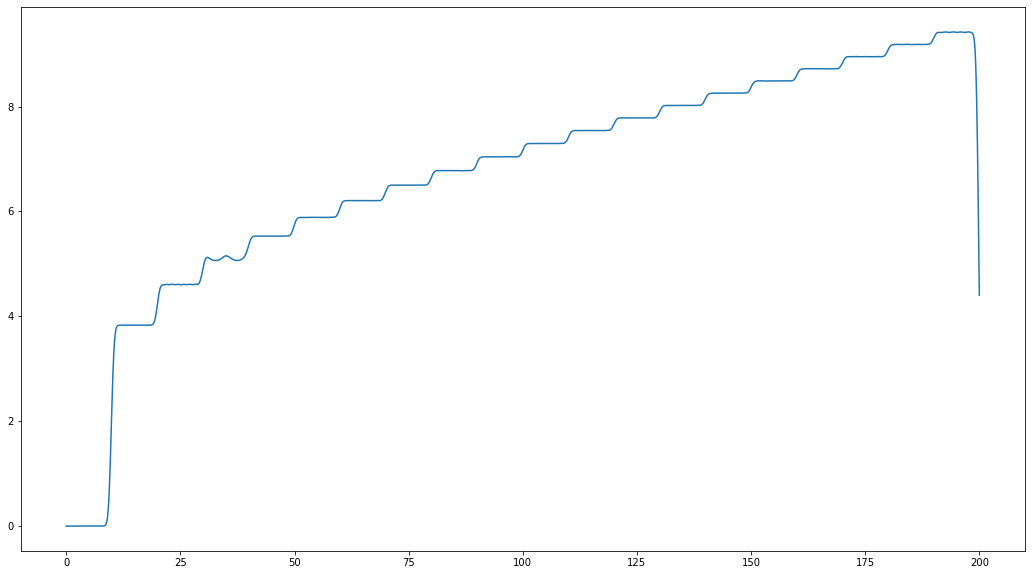

200000
20


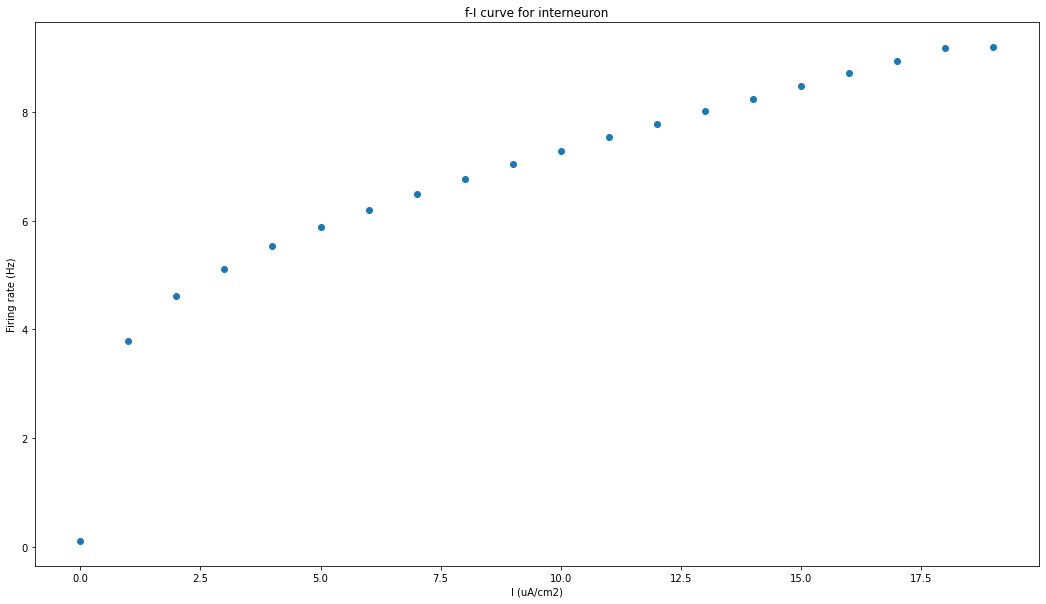

In [70]:
np_spike_times=np.array(spike_times.to_python())

binned_spks = a_utils.bin_spike_ms([spike_times,spike_times],sim_dur=200000)
firing_rate = a_utils.instant_rate(spike_train=spike_times,sim_dur=200000,stdev=500) * 1000
test_rate = firing_rate_from_binary(binned_spks[0],sigma_ms=500)
print("shape ", np.shape(test_rate))
plt.figure(figsize=(18,10))
plt.plot(time_arr,firing_rate)
plt.show()
print(len(firing_rate))
mean_list=[]
for i in range(20):
    mean_list.append(np.mean(firing_rate[i*10000:(i*10000)+10000]))

i_list = [i for i in range(20)]
print(len(mean_list))
plt.figure(figsize=(18,10))
plt.title("f-I curve for interneuron")
plt.xlabel("I (uA/cm2)")
plt.ylabel("Firing rate (Hz)")
plt.scatter(i_list,mean_list)
plt.show()